# Distance between protein termini

Atomic distance between the N- and C-terminal residues of every structure in `data/pdbs`, with the 5th, 10th, 25th and 50th percentiles marked.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa
from scipy.spatial import ConvexHull


def load_structure(pdb_path):
    return PDBParser(QUIET=True).get_structure(Path(pdb_path).stem, str(pdb_path))


def terminal_distance(pdb_path, mode='CA', structure=None):
    """Distance (Angstrom) between the N- and C-terminal residues of every chain.

    mode 'CA'        CA of the first residue -> CA of the last residue (default)
    mode 'backbone'  backbone N of the first residue -> backbone C of the last
    mode 'min'       closest atom pair between the two terminal residues

    Pass ``structure`` to reuse an already-parsed structure instead of re-reading the file.
    """
    if structure is None:
        structure = load_structure(pdb_path)
    model = next(structure.get_models())

    records = []
    for chain in model:
        residues = [r for r in chain if is_aa(r, standard=False)]
        if len(residues) < 2:
            continue
        n_term, c_term = residues[0], residues[-1]

        if mode == 'CA':
            if 'CA' not in n_term or 'CA' not in c_term:
                continue
            distance = n_term['CA'] - c_term['CA']
        elif mode == 'backbone':
            if 'N' not in n_term or 'C' not in c_term:
                continue
            distance = n_term['N'] - c_term['C']
        elif mode == 'min':
            distance = min(a - b for a in n_term.get_atoms() for b in c_term.get_atoms())
        else:
            raise ValueError(f"unknown mode {mode!r}, expected 'CA', 'backbone' or 'min'")

        records.append({
            'structure_id': Path(pdb_path).stem,
            'chain': chain.id,
            'n_residues': len(residues),
            'distance': distance,
        })
    return records


def collect_terminal_distances(pdb_folder='../data/pdbs', mode='CA'):
    """Terminal distances for every PDB file in a folder, as a DataFrame."""
    records = []
    for pdb_path in sorted(Path(pdb_folder).glob('*.pdb')):
        try:
            records.extend(terminal_distance(pdb_path, mode=mode))
        except Exception as exc:
            print(f'skipping {pdb_path.name}: {exc}')
    return pd.DataFrame.from_records(records, columns=['structure_id', 'chain', 'n_residues', 'distance'])

In [4]:
# Blue ordinal ramp, light -> dark, for the ordered percentile markers.
PERCENTILE_COLORS = ['#86b6ef', '#3987e5', '#256abf', '#104281']
PERCENTILE_DASHES = [(0, (1, 2)), (0, (4, 2)), (0, (7, 2)), (0, ())]


def plot_terminal_distance_distribution(distances, percentiles=(5, 10, 25, 50), bins=40,
                                        ax=None, title='N- to C-terminus distance', value_format='{:.1f} \u00c5',
                                        xlabel='Distance between terminal C\u03b1 atoms (\u00c5)'):
    """Histogram of terminal distances with the requested percentiles marked."""
    values = np.asarray(pd.Series(distances).dropna(), dtype=float)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    counts, _, _ = ax.hist(values, bins=bins, color='#d5d4cf', edgecolor='#fcfcfb', linewidth=2)

    cuts = np.percentile(values, percentiles)
    top = counts.max()
    for i, (pct, cut) in enumerate(zip(percentiles, cuts)):
        color = PERCENTILE_COLORS[i % len(PERCENTILE_COLORS)]
        ax.axvline(cut, color=color, linewidth=2, linestyle=PERCENTILE_DASHES[i % len(PERCENTILE_DASHES)])
        # Label each line directly, rotated, so close-together percentiles never collide.
        ax.annotate(f'p{pct} · ' + value_format.format(cut), xy=(cut, top * 1.08),
                    xytext=(5, 0), textcoords='offset points', rotation=90,
                    color=color, fontsize=9, fontweight='bold', va='top', ha='left')

    ax.set_xlabel(xlabel, color='#52514e')
    ax.set_ylabel('Structures', color='#52514e')
    ax.set_title(f'{title}  (n = {len(values)})', color='#0b0b0b', fontsize=12, loc='left')
    ax.set_ylim(0, top * 1.10)
    ax.grid(axis='y', color='#e8e7e3', linewidth=1)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color('#c3c2b7')
    ax.tick_params(colors='#52514e', length=0)
    return ax

In [5]:
distances = collect_terminal_distances('../data/pdbs', mode='CA')
print(f'{len(distances)} chains from {distances["structure_id"].nunique()} structures')
distances['distance'].describe()

547 chains from 547 structures


count    547.000000
mean      86.649994
std       21.481722
min        7.251644
25%       73.701069
50%       87.801170
75%       99.477249
max      188.149994
Name: distance, dtype: float64

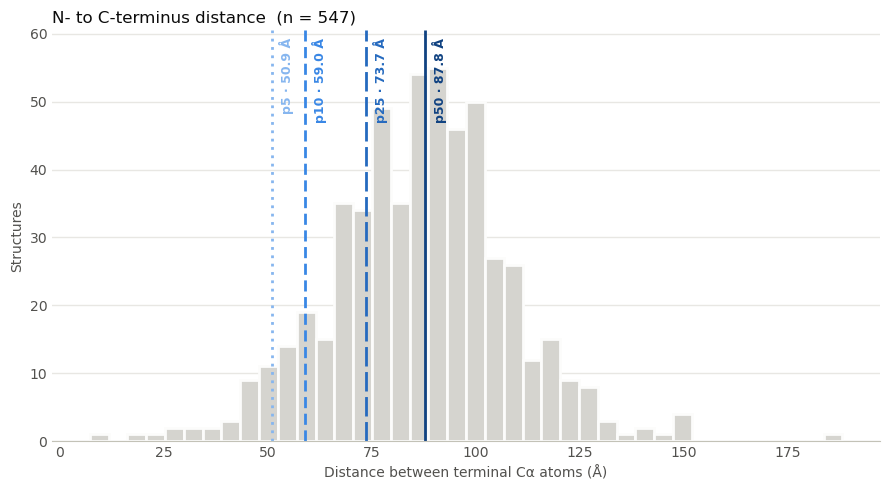

In [6]:
ax = plot_terminal_distance_distribution(distances['distance'], percentiles=(5, 10, 25, 50))
ax.figure.tight_layout()

## Relative to protein size

The same distance divided by the protein diameter (the largest distance between any two of its atoms), so a compact and an elongated protein are comparable. 0 means the termini meet, 1 means they sit at opposite ends of the longest axis.

In [ ]:
def protein_diameter(entity, atoms='all'):
    """Largest distance (Angstrom) between any two atoms of a chain or structure.

    atoms 'all'  every atom (default); or an atom name such as 'CA' to restrict the span.
    """
    coords = np.array([a.get_coord() for a in entity.get_atoms()
                       if atoms == 'all' or a.get_id() == atoms])
    if len(coords) < 2:
        return np.nan
    try:
        # The diameter of a point cloud is always realised by two hull vertices.
        candidates = coords[ConvexHull(coords).vertices]
    except Exception:
        candidates = coords  # degenerate (collinear / coplanar) chain
    return np.linalg.norm(candidates[:, None, :] - candidates[None, :, :], axis=-1).max()


RATIO_COLUMNS = ['structure_id', 'chain', 'n_residues', 'distance', 'diameter', 'ratio']


def terminal_ratios(pdb_path, mode='CA', atoms='all'):
    """Terminal distance, diameter and their ratio for every chain of one PDB file."""
    structure = load_structure(pdb_path)
    chains = {chain.id: chain for chain in next(structure.get_models())}

    records = terminal_distance(pdb_path, mode=mode, structure=structure)
    for record in records:
        record['diameter'] = protein_diameter(chains[record['chain']], atoms=atoms)
        record['ratio'] = record['distance'] / record['diameter']
    for record in records:
    return records


def collect_terminal_ratios(pdb_folder='../data/pdbs', mode='CA', atoms='all'):
    """Terminal distance, protein diameter and their ratio for every PDB file in a folder."""
    records = []
    for pdb_path in sorted(Path(pdb_folder).glob('*.pdb')):
        try:
            records.extend(terminal_ratios(pdb_path, mode=mode, atoms=atoms))
        except Exception as exc:
            print(f'skipping {pdb_path.name}: {exc}')
    return pd.DataFrame.from_records(records, columns=RATIO_COLUMNS)


def plot_terminal_ratio_distribution(ratios, percentiles=(5, 10, 25, 50), bins=40, ax=None,
                                     title='N- to C-terminus distance relative to protein diameter'):
    """Histogram of terminal-distance / diameter ratios with the requested percentiles marked."""
    ax = plot_terminal_distance_distribution(
        ratios, percentiles=percentiles, bins=bins, ax=ax, title=title,
        value_format='{:.2f}', xlabel='Terminal distance / protein diameter')
    ax.set_xlim(0, 1)
    return ax

In [14]:
ratios = collect_terminal_ratios('../data/pdbs', mode='CA', atoms='all')
ratios[['distance', 'diameter', 'ratio']].describe()

,distance,diameter,ratio
count,547.000000,547.000000,547.000000
mean,86.649994,105.335930,0.817457
std,21.481722,16.079718,0.135960
min,7.251644,73.625252,0.094652
25%,73.701069,93.623478,0.754707
50%,87.801170,103.888405,0.848786
75%,99.477249,115.933334,0.921222
max,188.149994,196.158722,0.981368


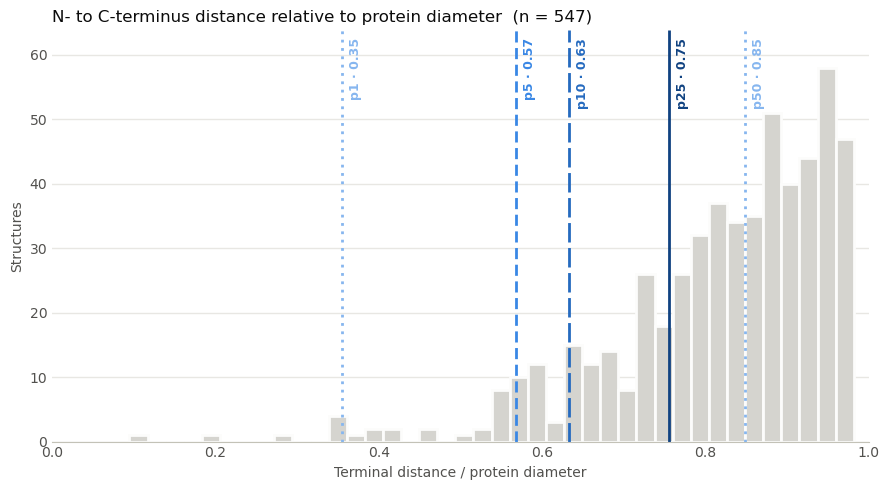

In [10]:
ax = plot_terminal_ratio_distribution(ratios['ratio'], percentiles=(1, 5, 10, 25, 50))
ax.figure.tight_layout()

## A single protein

Both numbers for one UniProt id, looked up straight from `data/pdbs`.

In [15]:
def terminal_metrics(protein_id, pdb_folder='../data/pdbs', mode='CA', atoms='all'):
    """Absolute and relative terminal distance for a single protein in the PDB folder.

    Returns one row per chain: the absolute distance in Angstrom, the protein diameter,
    and the ratio of the two. For a monomer, use ``.iloc[0]`` to get the values as a Series.
    """
    pdb_path = Path(pdb_folder) / f'{protein_id}.pdb'
    if not pdb_path.exists():
        raise FileNotFoundError(f'no structure for {protein_id!r} in {pdb_folder}')
    return pd.DataFrame.from_records(
        terminal_ratios(pdb_path, mode=mode, atoms=atoms), columns=RATIO_COLUMNS)

In [16]:
terminal_metrics('Q19975')

,structure_id,chain,n_residues,distance,diameter,ratio
0,Q19975,A,298,17.869827,88.050613,0.202949
